# Notebook 02: Markov Decision Processes (MDPs)

**Series:** Reinforcement Learning Basics (2/20)

---

## 1. The Markov Property

A state $S_t$ is **Markov** if and only if:

$$P[S_{t+1} | S_t] = P[S_{t+1} | S_1, S_2, \ldots, S_t]$$

**"The future is independent of the past given the present."**

The current state captures all relevant information from the history. No need to remember the past — the state is a **sufficient statistic**.

### Why is this important?
- Makes the problem **tractable** — we only need to consider current state
- Enables **recursive** solutions (Bellman equations)
- Most real-world problems can be approximately Markov with proper state representation

## 2. Formal MDP Definition

A **Markov Decision Process** is a tuple $(\mathcal{S}, \mathcal{A}, P, R, \gamma)$:

| Component | Symbol | Definition |
|-----------|--------|------------|
| State space | $\mathcal{S}$ | Finite set of states |
| Action space | $\mathcal{A}$ | Finite set of actions |
| Transition probability | $P$ | $P(s'|s,a) = \Pr[S_{t+1}=s'|S_t=s, A_t=a]$ |
| Reward function | $R$ | $R(s,a,s') = \mathbb{E}[R_{t+1}|S_t=s, A_t=a, S_{t+1}=s']$ |
| Discount factor | $\gamma$ | $\gamma \in [0,1]$ |

### Transition Probability Properties
For all $s \in \mathcal{S}, a \in \mathcal{A}$:
$$\sum_{s' \in \mathcal{S}} P(s'|s,a) = 1 \quad \text{and} \quad P(s'|s,a) \geq 0$$

## 3. Policy

A **policy** $\pi$ defines the agent's behavior:

**Stochastic policy:** $\pi(a|s) = \Pr[A_t = a | S_t = s]$

**Deterministic policy:** $\pi(s) = a$ (maps each state to one action)

A policy is **stationary** if it depends only on the current state, not on time: $\pi(a|s)$ is the same for all $t$.

## 4. Value Functions

### State-Value Function
$$V^\pi(s) = \mathbb{E}_\pi[G_t | S_t = s] = \mathbb{E}_\pi\left[\sum_{k=0}^{\infty} \gamma^k R_{t+k+1} \,\Big|\, S_t = s\right]$$

*"How good is it to be in state $s$ under policy $\pi$?"*

### Action-Value Function
$$Q^\pi(s, a) = \mathbb{E}_\pi[G_t | S_t = s, A_t = a] = \mathbb{E}_\pi\left[\sum_{k=0}^{\infty} \gamma^k R_{t+k+1} \,\Big|\, S_t = s, A_t = a\right]$$

*"How good is it to take action $a$ in state $s$ under policy $\pi$?"*

### Relationship between V and Q
$$V^\pi(s) = \sum_{a \in \mathcal{A}} \pi(a|s) \, Q^\pi(s, a)$$

$$Q^\pi(s,a) = \sum_{s'} P(s'|s,a)\left[R(s,a,s') + \gamma V^\pi(s')\right]$$

## 5. Optimal Value Functions

$$V^*(s) = \max_\pi V^\pi(s) \quad \forall s \in \mathcal{S}$$

$$Q^*(s,a) = \max_\pi Q^\pi(s,a) \quad \forall s \in \mathcal{S}, a \in \mathcal{A}$$

An **optimal policy** $\pi^*$ achieves the optimal value in every state:
$$\pi^*(s) = \arg\max_a Q^*(s, a)$$

### Theorem: Existence of Optimal Policy
For any finite MDP, there exists at least one deterministic optimal policy $\pi^*$ such that:
- $V^{\pi^*}(s) = V^*(s) \quad \forall s$
- $Q^{\pi^*}(s,a) = Q^*(s,a) \quad \forall s, a$

<>:102: SyntaxWarning: invalid escape sequence '\p'
<>:102: SyntaxWarning: invalid escape sequence '\p'
C:\Users\Milan Amrut Joshi\AppData\Local\Temp\ipykernel_55660\2813218290.py:102: SyntaxWarning: invalid escape sequence '\p'
  ax.set_ylabel('$V^\pi(s)$')


Student MDP (3 states: Class1, Class2, Passed)

V^pi (random policy): [ 52.01  66.91 100.  ]
V^pi (study policy):  [ 77.2  88.  100. ]

Q^pi (random policy):
[[ 58.22  45.81]
 [ 88.    45.81]
 [100.   100.  ]]


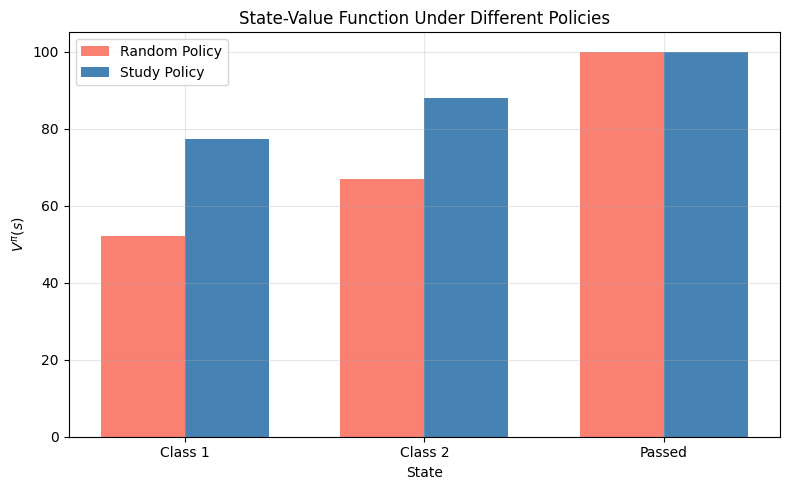

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================
# MDP Class Implementation
# ============================================

class MDP:
    """
    Finite Markov Decision Process.

    Parameters:
        n_states: number of states
        n_actions: number of actions
        P: transition probabilities P[s, a, s'] = P(s'|s,a)
        R: reward function R[s, a, s']
        gamma: discount factor
    """
    def __init__(self, n_states, n_actions, P, R, gamma=0.99):
        self.n_states = n_states
        self.n_actions = n_actions
        self.P = P  # shape: (n_states, n_actions, n_states)
        self.R = R  # shape: (n_states, n_actions, n_states)
        self.gamma = gamma

    def expected_reward(self, s, a):
        """E[R | s, a] = sum_s' P(s'|s,a) * R(s,a,s')"""
        return np.sum(self.P[s, a] * self.R[s, a])

    def compute_v_pi(self, pi):
        """
        Compute V^pi by solving the linear system:
        V = R^pi + gamma * P^pi * V
        => (I - gamma * P^pi) V = R^pi
        """
        # Build P^pi and R^pi
        P_pi = np.zeros((self.n_states, self.n_states))
        R_pi = np.zeros(self.n_states)
        for s in range(self.n_states):
            for a in range(self.n_actions):
                P_pi[s] += pi[s, a] * self.P[s, a]
                R_pi[s] += pi[s, a] * self.expected_reward(s, a)
        # Solve: (I - gamma * P_pi) V = R_pi
        A = np.eye(self.n_states) - self.gamma * P_pi
        V = np.linalg.solve(A, R_pi)
        return V

    def compute_q_pi(self, pi):
        """Compute Q^pi from V^pi."""
        V = self.compute_v_pi(pi)
        Q = np.zeros((self.n_states, self.n_actions))
        for s in range(self.n_states):
            for a in range(self.n_actions):
                Q[s, a] = np.sum(self.P[s, a] * (self.R[s, a] + self.gamma * V))
        return Q


# --- Example: Student MDP (simplified) ---
# States: 0=Class1, 1=Class2, 2=Class3, 3=Pass, 4=Facebook, 5=Sleep
# Simplified to 3 states for clarity
n_s, n_a = 3, 2  # 3 states, 2 actions (study/slack)
P = np.zeros((n_s, n_a, n_s))
R = np.zeros((n_s, n_a, n_s))

# State 0: action 0 (study) -> state 1, reward -2
P[0, 0, 1] = 1.0;  R[0, 0, 1] = -2
# State 0: action 1 (slack) -> state 0, reward -1
P[0, 1, 0] = 1.0;  R[0, 1, 0] = -1
# State 1: action 0 (study) -> state 2, reward -2
P[1, 0, 2] = 1.0;  R[1, 0, 2] = -2
# State 1: action 1 (slack) -> state 0, reward -1
P[1, 1, 0] = 1.0;  R[1, 1, 0] = -1
# State 2 (terminal): absorbing
P[2, 0, 2] = 1.0;  R[2, 0, 2] = 10
P[2, 1, 2] = 1.0;  R[2, 1, 2] = 10

mdp = MDP(n_s, n_a, P, R, gamma=0.9)

# Random policy
pi_random = np.ones((n_s, n_a)) / n_a
V_random = mdp.compute_v_pi(pi_random)
Q_random = mdp.compute_q_pi(pi_random)

# Study-always policy
pi_study = np.zeros((n_s, n_a))
pi_study[:, 0] = 1.0
V_study = mdp.compute_v_pi(pi_study)

print("Student MDP (3 states: Class1, Class2, Passed)")
print(f"\nV^pi (random policy): {np.round(V_random, 2)}")
print(f"V^pi (study policy):  {np.round(V_study, 2)}")
print(f"\nQ^pi (random policy):\n{np.round(Q_random, 2)}")

# Visualize
states = ['Class 1', 'Class 2', 'Passed']
x = np.arange(len(states))
width = 0.35
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, V_random, width, label='Random Policy', color='salmon')
ax.bar(x + width/2, V_study, width, label='Study Policy', color='steelblue')
ax.set_xlabel('State')
ax.set_ylabel('$V^\pi(s)$')
ax.set_title('State-Value Function Under Different Policies')
ax.set_xticks(x)
ax.set_xticklabels(states)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Summary

| Concept | Formula |
|---------|---------|
| **Markov Property** | $P[S_{t+1}|S_t] = P[S_{t+1}|S_1,\ldots,S_t]$ |
| **State-Value** | $V^\pi(s) = \mathbb{E}_\pi[G_t|S_t=s]$ |
| **Action-Value** | $Q^\pi(s,a) = \mathbb{E}_\pi[G_t|S_t=s, A_t=a]$ |
| **V-Q Relationship** | $V^\pi(s) = \sum_a \pi(a|s) Q^\pi(s,a)$ |
| **Optimal Value** | $V^*(s) = \max_\pi V^\pi(s)$ |

**Next:** Notebook 03 — Bellman Equations